# XRD Pattern Diffusion Augmentation Notebook

This notebook demonstrates how to use the trained diffusion model to augment XRD patterns with various parameters, allowing you to see how well the augmentation works on original data.

## Features:
- Load trained diffusion model weights with selection option
- Test with dataset_sample_451.pt
- Interactive parameter exploration
- Visual comparison of original vs augmented patterns
- Quality metrics and analysis
- Export functionality for augmented data

## 1. Setup and Environment

In [17]:
# Import necessary libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Add diffusion module to path
sys.path.append('diffusion')
sys.path.append('diffusion classification pipeline')

# Import diffusion components
from diffusion.models.complete_model import ImprovedDiffusionDenoiser
from diffusion.diffusion.process import DiffusionProcess
from diffusion.datasets.xrd_dataset import XRDTransformDataset
from diffusion.training.config import TrainingConfig

# Import validation components for quality assessment
try:
    from validation_suite import ValidationSuite
except ImportError:
    print("Validation suite not available, using basic validation")

print("Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Environment setup complete!
PyTorch version: 2.5.1+cu121
CUDA available: True
Using device: cuda


## 2. Model Weight Selection and Loading

In [18]:
# Available model weights
model_options = {
    "XRD Diffusion Model": "models/xrd_diffusion/improved_diffusion_model_best.pth",
    "XRD Diffusion Model v1": "models/xrd_diffusion_1/improved_diffusion_model_best.pth",
    "xrd-dev" : "diffusion/models/xrd_diffusion/improved_diffusion_model_best.pth" 
}

# Select model (change this to switch between models)
selected_model = "xrd-dev"  # or "XRD Diffusion Model v1"
model_path = model_options[selected_model]

print(f"Loading model: {selected_model}")
print(f"Model path: {model_path}")

# Check if model file exists
if not os.path.exists(model_path):
    print(f"❌ Model file not found: {model_path}")
else:
    try:
        # Load training configuration
        config = TrainingConfig()
        
        # Model configuration from training config
        model_config = {
            'in_channels': 1,
            'hidden_channels': config.hidden_channels,
            'time_embedding_dim': config.time_embedding_dim,
            'num_res_blocks': config.num_res_blocks,
            'attention_levels': config.attention_levels,
            'num_levels': config.num_levels,
            'temperature_condition': True
        }
        
        print(f"Using training config: {model_config}")
        
        model = ImprovedDiffusionDenoiser(**model_config).to(device)
        
        # Load weights
        checkpoint = torch.load(model_path, map_location=device)
        
        # Handle different checkpoint formats
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"✅ Loaded model state dict from checkpoint")
        else:
            model.load_state_dict(checkpoint)
            print(f"✅ Loaded model weights directly")
        
        model.eval()
        
        # Initialize diffusion process
        diffusion = DiffusionProcess(
            num_timesteps=config.num_timesteps,
            schedule_type='cosine',
            device=device
        )
        
        # Print model info
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"📊 Model loaded successfully!")
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        import traceback
        traceback.print_exc()

Loading model: xrd-dev
Model path: diffusion/models/xrd_diffusion/improved_diffusion_model_best.pth
Using training config: {'in_channels': 1, 'hidden_channels': 16, 'time_embedding_dim': 256, 'num_res_blocks': 2, 'attention_levels': [1, 2], 'num_levels': 2, 'temperature_condition': True}
✅ Loaded model state dict from checkpoint
📊 Model loaded successfully!
Total parameters: 236,689
Trainable parameters: 236,689


## 3. Load Test Data

Loading test data from: data/dataset_sample_451.pt
✅ Test data loaded successfully!
Data type: <class 'dict'>
Dictionary keys: ['filenames', 'patterns']
  filenames: <class 'list'>
  patterns: torch.Size([451, 4500]) (torch.float32)
Using first pattern from 451 available patterns

📊 Sample XRD pattern prepared:
Shape: torch.Size([1, 1, 4500])
Min value: 0.0000
Max value: 1.0000
Mean value: 0.0016


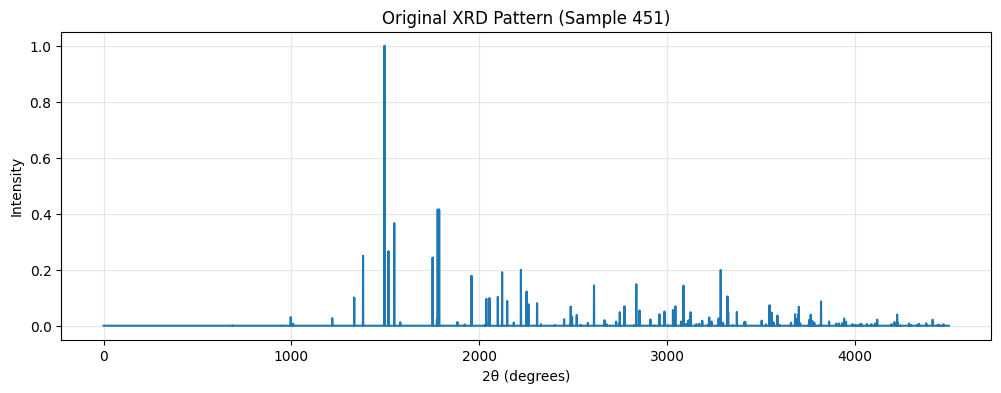

In [25]:
# Load test data from dataset_sample_451.pt
test_data_path = "data/dataset_sample_451.pt"

def load_test_data():
    if not os.path.exists(test_data_path):
        print(f"❌ Test data file not found: {test_data_path}")
        return None
    
    try:
        print(f"Loading test data from: {test_data_path}")
        test_data = torch.load(test_data_path, map_location=device)
        
        print(f"✅ Test data loaded successfully!")
        print(f"Data type: {type(test_data)}")
        
        if isinstance(test_data, dict):
            print(f"Dictionary keys: {list(test_data.keys())}")
            for key, value in test_data.items():
                if isinstance(value, torch.Tensor):
                    print(f"  {key}: {value.shape} ({value.dtype})")
                else:
                    print(f"  {key}: {type(value)}")
        elif isinstance(test_data, torch.Tensor):
            print(f"Tensor shape: {test_data.shape}")
            print(f"Tensor dtype: {test_data.dtype}")
        
        return test_data
        
    except Exception as e:
        print(f"❌ Error loading test data: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Load the test data
test_sample = load_test_data()

# Prepare sample data for augmentation
if test_sample is not None:
    # Handle different data formats
    if isinstance(test_sample, dict):
        # Check for known keys and extract XRD patterns
        if 'patterns' in test_sample:
            sample_xrd = test_sample['patterns']
        elif 'synth_xrd' in test_sample:
            sample_xrd = test_sample['synth_xrd']
        elif 'real_xrd' in test_sample:
            sample_xrd = test_sample['real_xrd']
        elif 'data' in test_sample:
            sample_xrd = test_sample['data']
        else:
            # Take the first tensor value
            tensor_values = [v for v in test_sample.values() if isinstance(v, torch.Tensor)]
            if tensor_values:
                sample_xrd = tensor_values[0]
            else:
                print("❌ No tensor data found in the dictionary")
                sample_xrd = None
    else:
        sample_xrd = test_sample
    
    if sample_xrd is not None:
        # Take just one sample for demonstration (first pattern)
        if sample_xrd.dim() == 2 and sample_xrd.shape[0] > 1:
            sample_xrd = sample_xrd[0:1]  # Take first pattern only
            print(f"Using first pattern from {test_sample['patterns'].shape[0]} available patterns")
        
        # Ensure proper shape [batch, channels, length]
        if sample_xrd.dim() == 1:
            sample_xrd = sample_xrd.unsqueeze(0).unsqueeze(0)  # [1, 1, length]
        elif sample_xrd.dim() == 2:
            sample_xrd = sample_xrd.unsqueeze(1)  # [batch, 1, length]
        
        sample_xrd = sample_xrd.to(device)
        print(f"\n📊 Sample XRD pattern prepared:")
        print(f"Shape: {sample_xrd.shape}")
        print(f"Min value: {sample_xrd.min().item():.4f}")
        print(f"Max value: {sample_xrd.max().item():.4f}")
        print(f"Mean value: {sample_xrd.mean().item():.4f}")
        
        # Plot the original sample
        plt.figure(figsize=(12, 4))
        plt.plot(sample_xrd[0, 0].cpu().numpy())
        plt.title("Original XRD Pattern (Sample 451)")
        plt.xlabel("2θ (degrees)")
        plt.ylabel("Intensity")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("❌ Could not extract XRD pattern data")
else:
    print("⚠️  No test data available for augmentation")

## 4. Augmentation Parameter Exploration

## 5. Interactive Augmentation Interface

## 6. Batch Augmentation and Analysis

## 7. Export Functionality

## 9. Summary and Next Steps

This notebook provides a comprehensive interface for exploring XRD pattern augmentation using your trained diffusion model. Here's what you can do:

### Key Features:
1. **Model Selection**: Choose between different trained model weights
2. **Interactive Parameters**: Real-time adjustment of augmentation parameters
3. **Visual Comparison**: Side-by-side plots of original vs augmented patterns
4. **Quality Metrics**: Quantitative assessment of augmentation quality
5. **Batch Analysis**: Compare different augmentation strength levels
6. **Export Functionality**: Save augmented data for training use
7. **Advanced Analysis**: Peak detection and parameter sensitivity studies

### Usage Tips:
- Start with light augmentation parameters and gradually increase
- Monitor the correlation metric to ensure patterns remain realistic
- Use batch analysis to find optimal parameter ranges
- Export promising augmentations for training data enhancement

### Next Steps:
1. Integrate augmented data into your training pipeline
2. Test augmentation on different types of XRD patterns
3. Evaluate model performance with augmented training data
4. Fine-tune augmentation parameters based on downstream task performance